In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
def show(fitsfile):
    # Load the FITS file
    hdul1 = fits.open(fitsfile)
    print(hdul[1])

In [3]:
def getarray(fitsfile):
    # Load the FITS file
    hdul1 = fits.open(fitsfile)
    x = []
    for i in range(len(hdul1[2].data)):
        x.append(hdul1[2].data[i][3])
    for i in range(len(hdul1[3].data)):
        x.append(hdul1[3].data[i][3])
    y = np.array(x)
    
    return(y)

In [4]:
xipm_des = getarray("../data/dv/sim_2pt-NLA-cosmoDESY3.fits")
xipm_cosmogrid = getarray("../data/dv/sim_2pt-NLA-cosmoCosmoG.fits")

In [5]:
print(len(xipm_des))
print(len(xipm_cosmogrid))

400
400


In [6]:
ratio = xipm_des/xipm_cosmogrid

In [7]:
print(ratio)

[0.37085238 0.37560264 0.3801489  0.38415392 0.38723776 0.38903523
 0.3892803  0.38790081 0.38508162 0.38126513 0.37707637 0.37320232
 0.37025623 0.36867898 0.36870581 0.37040631 0.37376581 0.37868621
 0.38496574 0.39229881 0.49255696 0.49569009 0.49827129 0.50000542
 0.50063039 0.49998666 0.49808526 0.49514516 0.49156514 0.48783574
 0.48443302 0.4817391  0.48000246 0.47933732 0.47975216 0.48119097
 0.48357335 0.48679751 0.49064392 0.49464556 0.47800478 0.48101381
 0.48336589 0.48474426 0.48489234 0.48369461 0.48124098 0.47784521
 0.47398571 0.47019145 0.46692996 0.46454255 0.4632289  0.46306912
 0.46406174 0.46615233 0.46928328 0.47332671 0.47822909 0.48338637
 0.47429456 0.47739392 0.47990845 0.48147044 0.48177209 0.48064987
 0.4781521  0.47455838 0.47032441 0.46597389 0.46199231 0.45876283
 0.45654502 0.45548982 0.45566838 0.45708752 0.45975043 0.4636719
 0.46881502 0.4735188  0.78068471 0.77861197 0.77606536 0.77317092
 0.77012903 0.76716621 0.76446462 0.76209711 0.75999917 0.75799

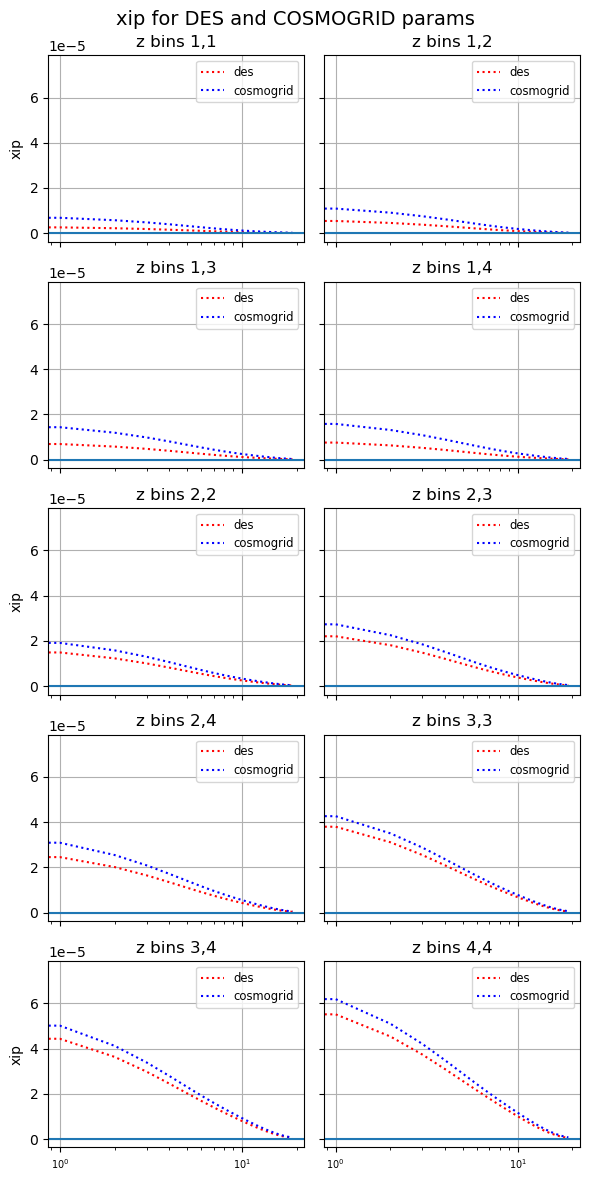

In [32]:
xipm_des_sec = np.split(xipm_des, 20)[:200]
xipm_cmg_sec = np.split(xipm_cosmogrid, 20)[:200]

indx = [[1,1],[1,2],[1,3],[1,4],[2,2],[2,3],[2,4],[3,3],[3,4],[4,4]]

fig, axs = plt.subplots(5, 2, figsize=(6, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.arange(20)
    ax.plot(x_values, xipm_des_sec[i], color='r', ls=':',label='des')
    ax.plot(x_values, xipm_cmg_sec[i], color='b', ls=':',label='cosmogrid')
    ax.axhline(y=0)
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]}')
    if i >= 16:
        ax.set_xlabel(r"Index")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel(r"xip")
        
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"xip for DES and COSMOGRID params", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
plt.show()

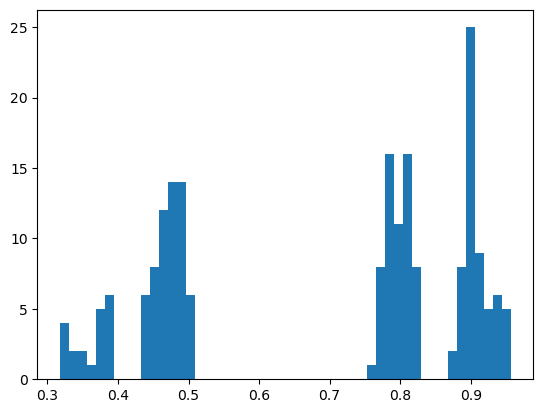

In [8]:
plt.hist(ratio[200:400],50)
plt.show()

In [9]:
from scipy import stats

def mean_wo(data, z_threshold=1.5):
    # Compute the Z-scores of the data
    z_scores = stats.zscore(data)
    # Filter out the data points with a Z-score greater than the threshold
    filtered_data = data[np.abs(z_scores) < z_threshold]
    # Compute the mean of the filtered data
    mean = np.mean(filtered_data)
    return mean

In [10]:
new_matrix = np.ndarray(shape=(10,20))
for i in range(10):
    #new_matrix[i] = np.concatenate((ratio[i*20:(i+1)*20], ratio[200+i*20:200+(i+1)*20]))
    new_matrix[i] = ratio[i*20:(i+1)*20]

In [11]:
print(np.mean(ratio))
print(np.median(ratio))
print(mean_wo(ratio))

0.6765224174603436
0.767921817099851
0.7001225531981949


In [12]:
print(np.sqrt(mean_wo(new_matrix[0])))

0.6154289246213622


In [13]:
print(np.sqrt(mean_wo(new_matrix[4])))

0.8701181693449714


In [14]:
print(np.sqrt(mean_wo(new_matrix[7])))

0.927485483803646


In [15]:
print(np.sqrt(mean_wo(new_matrix[9])))

0.9245707197726286


In [19]:
#see if doing sqrt of auto recovers the rest:

#1,2
print(np.sqrt(mean_wo(new_matrix[0]))*np.sqrt(mean_wo(new_matrix[4])))
print((mean_wo(new_matrix[0])+mean_wo(new_matrix[4]))/2)
print(mean_wo(new_matrix[1]))

0.5354958892534841
0.5679291949424254
0.4900943746326627


In [20]:
#see if doing sqrt of auto recovers the rest:

#1,3
print(np.sqrt(mean_wo(new_matrix[0]))*np.sqrt(mean_wo(new_matrix[7])))
print((mean_wo(new_matrix[0])+mean_wo(new_matrix[7]))/2)
print(mean_wo(new_matrix[2]))

0.5708013938992017
0.6194910419635449
0.47455945470678856


In [18]:
#see if doing sqrt of auto recovers the rest:

#1,4
print(np.sqrt(mean_wo(new_matrix[0]))*np.sqrt(mean_wo(new_matrix[9])))
print(mean_wo(new_matrix[3]))

0.5690075638060677
0.4687900072439934


In [81]:
#see if doing sqrt of auto recovers the rest:

#2,3
print(np.sqrt(mean_wo(new_matrix[4]))*np.sqrt(mean_wo(new_matrix[7])))
print(mean_wo(new_matrix[5]))

0.7985530493263937
0.7752845914876723


In [82]:
#see if doing sqrt of auto recovers the rest:

#2,4
print(np.sqrt(mean_wo(new_matrix[4]))*np.sqrt(mean_wo(new_matrix[9])))
print(mean_wo(new_matrix[6]))

0.7951299444619495
0.7622043315919939


In [83]:
#see if doing sqrt of auto recovers the rest:

#3,4
print(np.sqrt(mean_wo(new_matrix[7]))*np.sqrt(mean_wo(new_matrix[9])))
print(mean_wo(new_matrix[8]))

0.8441990003163631
0.8396303949179897
